# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen d maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!
## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
De wet van Ampère: $\oint_{\mathcal C} \mathbf H \cdot d\mathbf l = I_{\text{ingesloten}}$
We kiezen een contour $\mathcal C$ langs de as van de solenoïde.
Binnen de solenoïde zijn twee gebieden:
- lucht: lengte $L_s - z_p$
- plunjer: lengte $z_p$
Omdat alle windingen: $I_{ingesloten} = NI$
volgt: $H_{\text{lucht}}(L_s - z_p) + H_{\text{plunjer}} z_p = NI$

b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\

Relatie tussen $B$ en $H$: $B = \mu H$
Voor lucht: $B = \mu_0 H_{\text{lucht}}$
Voor de plunjer: $B = \mu_0 \mu_r H_{\text{plunjer}}$
Omdat normale component $B$ continu:$B_{\text{lucht}} = B_{\text{plunjer}} = B$

$$
z_p = L_s
$$

$$
B =
\frac{\mu_0 \mu_r N I}{L_s}
$$

Dit komt overeen met een solenoïde volledig gevuld met lineair magnetisch materiaal.

c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

De afgeleide formule:

$$
B(z_p) =
\frac{\mu_0 N I}
{(L_s - z_p) + \frac{z_p}{\mu_r}}
$$

voldoet aan de fysische randvoorwaarden en beschrijft hoe het magnetisch veld verandert als de plunjer verder in de spoel schuift.



Figuur: ![Alt](Digi2d1o1.jpg)

![Alt](Digi2deel1(2).jpg)
![Alt](Digi 2 deel 1 (4).jpg)

Figuur: ![Alt](Digi 2 deel 1 (2).jpg)

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

$$
W = \frac{1}{2} \int_{\mathcal V} \mathbf{H}\cdot \mathbf{B}\, d\tau
$$


$$
A == \pi r_s^2
$$

$$
W =
\frac{1}{2} A
\left[
H_{\text{lucht}} B (L_s - z_d)
+
H_{\text{plunjer}} B z_d
\right]
$$



$$
H_{\text{lucht}} = \frac{B}{\mu_0}, \qquad
H_{\text{plunjer}} = \frac{B}{\mu_0 \mu_r}
$$


$$
W =
\frac{1}{2} A \frac{B^2}{\mu_0}
\left[
(L_s - z_d) + \frac{z_d}{\mu_r}
\right]
$$


$$
B(z_d) =
\frac{\mu_0 N I}
{(L_s - z_d) + \frac{z_d}{\mu_r}}
$$

$$

W(z_d) =
\frac{1}{2}\pi r_s^2
\frac{\mu_0 N^2 I^2}
{(L_s - z_d) + \frac{z_d}{\mu_r}}

$$

Voeg jullie afleiding hier als png toe.

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

$$
F(z_p) = \frac{dW}{dz_p}
$$



$$
W(z_p) =
\frac{1}{2}\pi r_s^2
\frac{\mu_0 N^2 I^2}
{(L_s - z_p) + \frac{z_p}{\mu_r}}
$$

$$
D = (L_s - z_p) + \frac{z_p}{\mu_r}
$$


$$
W(z_p) = \frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2 \frac{1}{D}
$$



$$
\frac{dW}{dz_p}
=
\frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2
\left(-\frac{1}{D^2}\right)
\left(-1 + \frac{1}{\mu_r}\right)
$$


$$

F(z_p) =
\frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2
\frac{1 - \frac{1}{\mu_r}}
{\left((L_s - z_p) + \frac{z_p}{\mu_r}\right)^2}

$$

Voeg hier een png toe van jullie afleiding.

## Deel 2: Criteria opstellen

In dit deel kiezen we toepassingen en vertalen we die naar concrete ontwerpeisen.  
We werken verder met drie toepassingen:

1. een klepactuator  
2. een actuator voor een deurslot  
3. een deuractuator  

### Opdracht 4

a. Bedenk en schets vijf mogelijke toepassingen van een krachtactuator.  
b. Kies daaruit twee toepassingen waarmee je verder wilt rekenen.  
c. Schrijf voor die twee toepassingen op welke kracht minimaal nodig is en welke afmetingen ongeveer passen bij de toepassing.

Hieronder staan onze gekozen toepassingen en de krachten waarmee we in de rest van het notebook verder rekenen:

- **klepactuator:** minimale kracht ongeveer **2 N**
- **deurslotactuator:** minimale kracht ongeveer **5 N**
- **deuractuator:** minimale kracht ongeveer **40 N**

Deze waarden gebruiken we in deel 3 als ontwerpeis.

fotos van schetsen


**Opdracht 5**

Stel nu de belangrijkste criteria op voor de actuator.

Gebruik daarbij in ieder geval:

1. de beschikbare **voedingsspanning**
2. de maximale **stroom**
3. de **draaddiameter**
4. de benodigde **kracht**
5. een redelijke keuze voor het materiaal van de plunjer

Wij rekenen in de rest van het notebook verder met:

- gekozen stroombron: **9 V batterij**
- maximale stroom: **0.5 A**
- draaddiameter: **0.1 mm**
- plunjermateriaal: **ijzer**
- minimale kracht klep: **2 N**
- minimale kracht deurslot: **5 N**
- minimale kracht deuractuator: **40 N**

Hier staan de gekozen uitgangswaarden nog eens overzichtelijk bij elkaar.

### Gekozen invoer voor het ontwerp

- voedingsspanning: **9 V**
- maximale stroom: **0.5 A**
- draaddiameter: **0.1 mm**
- soortelijke weerstand koper: **1.68 × 10⁻⁸ Ωm**
- relatieve permeabiliteit plunjer: **μᵣ = 5000** (benadering voor zacht magnetisch materiaal)

### Gevraagde minimale krachten

- klepactuator: **2 N**
- deurslotactuator: **5 N**
- deuractuator: **40 N**

Vanaf hier gebruiken we overal dezelfde symbolen:

- $L_s$ = lengte van de spoel  
- $r_s$ = straal van de spoel  
- $d_\mathrm{draad}$ = diameter van de draad  
- $N$ = aantal windingen  
- $I$ = stroom  
- $l_\mathrm{draad,max}$ = maximaal beschikbare draadlengte

## Deel 3: Simuleren om de grenzen van het ontwerp te bepalen

In dit deel onderzoeken we welke ontwerpen haalbaar zijn.  
We doen dat door het **minimale** aantal windingen dat nodig is te vergelijken met het **maximale** aantal windingen dat mogelijk is.

We bekijken drie toepassingen:

1. een klepactuator  
2. een actuator voor een deurslot  
3. een deuractuator  

Voor de deuractuator nemen we aan:

- benodigde kracht: **40 N**
- voedingsbron: **9 V batterij**
- materiaal plunjer: **ijzer**
- straal spoel: **0.01 m**

Een ontwerp is haalbaar als:

$
N_{\max} \geq N_{\min}
$

We werken dit uit in opdrachten 6 t/m 10.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Vaste invoer uit deel 2
V_bron = 9.0                 # V
I_bron = 0.5                 # A
d_draad = 0.1e-3             # m
rho_koper = 1.68e-8          # ohm*m
mu_0 = 4 * np.pi * 1e-7
mu_r = 5000                  # benadering voor zacht ijzer

# Ontwerpeisen van de drie toepassingen
F_klep = 2.0                 # N
F_slot = 5.0                 # N
F_deur = 40.0                # N

r_klep = 0.005               # m
r_slot = 0.005               # m
r_deur = 0.01                # m

def maximale_draadlengte(V, I, d, rho=rho_koper):
    """Berekent de maximaal beschikbare draadlengte uit de elektrische beperking."""
    R_max = V / I
    A_draad = np.pi * (d / 2) ** 2
    return R_max * A_draad / rho

l_draad_max = maximale_draadlengte(V_bron, I_bron, d_draad)

print(f"Maximale draadlengte = {l_draad_max:.2f} m")

Maximale draadlengte = 8.41 m


**Opdracht 7**

Leid een formule af voor het minimale aantal windingen dat nodig is om een gevraagde kracht te leveren.

Gebruik achtereenvolgens:

$
H = nI,\qquad n = \frac{N}{L_s}
$

$
B = \mu_0 \mu_r H
$

en voor de kracht op de plunjer:

$
F = \frac{B^2 A}{2\mu_0}, \qquad A = \pi r_s^2
$

Herschrijf de vergelijking zodat $N$ links staat.

Samengevat geeft de afleiding:

$
H = \frac{NI}{L_s}
$

$
B = \mu_0 \mu_r \frac{NI}{L_s}
$

$
F = \frac{B^2 \pi r_s^2}{2\mu_0}
$

Invullen geeft:

$
F = \frac{\mu_0 \mu_r^2 \pi r_s^2 N^2 I^2}{2L_s^2}
$

In deze ontwerpbenadering nemen we, net als eerder in het notebook, de eenvoudig gebruikte vorm:

$
F \approx \frac{\mu_0 \mu_r \pi r_s^2 N^2 I^2}{2L_s^2}
$

Daaruit volgt voor het minimale aantal windingen:

$
N_{\min} = \sqrt{\frac{2FL_s^2}{\mu_0 \mu_r \pi r_s^2 I^2}}
$

Die relatie gebruiken we hieronder in de code.

We gaan nu de ontwerpvrijheid verkennen.

### Opdracht 8

Schrijf één functie die voor gegeven waarden van $L_s$, $r_s$, $d_\mathrm{draad}$, $I$ en $F_\mathrm{min}$ het volgende berekent:

1. het minimale aantal windingen dat nodig is
2. het maximale aantal windingen dat in de spoellengte past
3. het maximale aantal windingen dat mogelijk is met de beschikbare draadlengte
4. of het ontwerp haalbaar is

Gebruik:

$
N_{\max,1} = \frac{L_s}{d_\mathrm{draad}}
$

$
N_{\max,2} = \frac{l_\mathrm{draad,max}}{2\pi r_s}
$

$
N_{\max} = \min(N_{\max,1}, N_{\max,2})
$

In [3]:
def aantal_wikkelingen(L_s, r_s, d_draad, I, F_min, l_draad_max, mu_r=mu_r):
    """
    Berekent het minimale aantal windingen, het maximale aantal windingen
    en of het ontwerp haalbaar is.
    """
    N_min = np.sqrt((2 * F_min * L_s**2) / (mu_0 * mu_r * np.pi * r_s**2 * I**2))
    N_max_lengte = L_s / d_draad
    N_max_draad = l_draad_max / (2 * np.pi * r_s)
    N_max = min(N_max_lengte, N_max_draad)
    haalbaar = N_max >= N_min

    return {
        "N_min": N_min,
        "N_max_lengte": N_max_lengte,
        "N_max_draad": N_max_draad,
        "N_max": N_max,
        "haalbaar": haalbaar,
    }

# Voorbeeldcontrole
voorbeeld = aantal_wikkelingen(
    L_s=0.02,
    r_s=0.005,
    d_draad=d_draad,
    I=I_bron,
    F_min=F_klep,
    l_draad_max=l_draad_max,
)

for naam, waarde in voorbeeld.items():
    print(f"{naam}: {waarde}")

N_min: 113.88200694674833
N_max_lengte: 200.0
N_max_draad: 267.85714285714283
N_max: 200.0
haalbaar: True


Een parameterplot laat zien voor welke spoellengtes een ontwerp haalbaar is.

Als de lijn van $N_{\max}$ boven die van $N_{\min}$ ligt, dan is het ontwerp mogelijk.

Ter illustratie eerst een simpel voorbeeld:

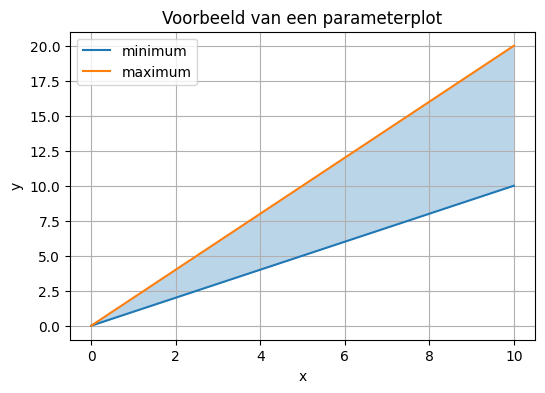

In [4]:
x = np.linspace(0, 10, 100)
y_min = x
y_max = 2 * x

plt.figure(figsize=(6, 4))
plt.fill_between(x, y_min, y_max, alpha=0.3)
plt.plot(x, y_min, label="minimum")
plt.plot(x, y_max, label="maximum")
plt.title("Voorbeeld van een parameterplot")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

**Opdracht 9**

Maak voor de drie actuatoren een parameterplot voor $L_s$ tussen **0.01 m** en **1.0 m** met **50 stappen**.

Plot per actuator:

- het minimale aantal windingen $N_{\min}$
- het maximale aantal windingen $N_{\max}$

Geef daarna kort aan bij welke spoellengtes het ontwerp haalbaar is.

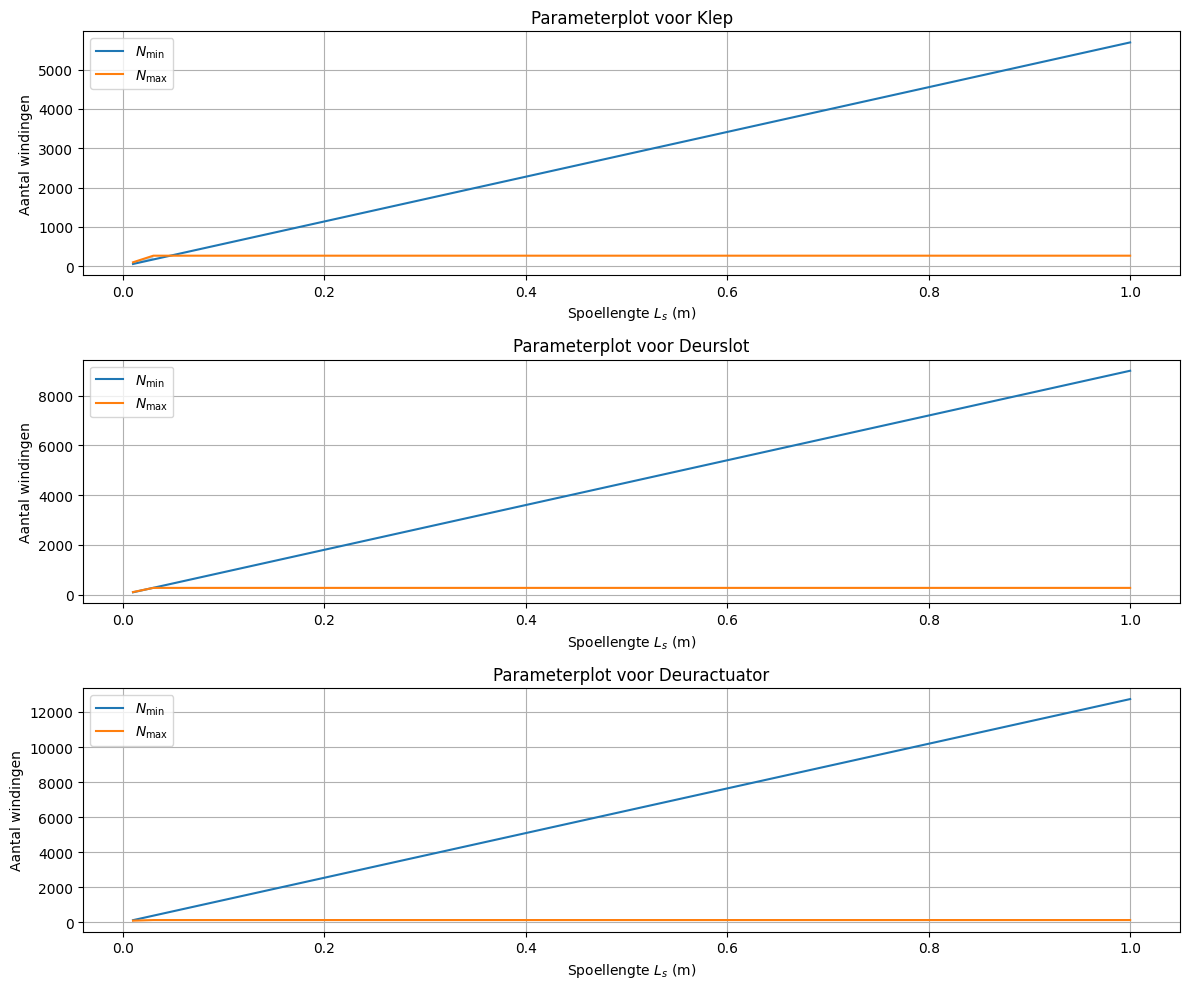

Klep: haalbaar ongeveer voor L_s tussen 0.010 m en 0.030 m.
Deurslot: haalbaar ongeveer voor L_s tussen 0.010 m en 0.010 m.
Deuractuator: niet haalbaar in het onderzochte bereik.


In [5]:
L_reeks = np.linspace(0.01, 1.0, 50)

actuatoren = {
    "Klep": {"F": F_klep, "r": r_klep},
    "Deurslot": {"F": F_slot, "r": r_slot},
    "Deuractuator": {"F": F_deur, "r": r_deur},
}

plt.figure(figsize=(12, 10))
samenvatting_haalbaarheid = {}

for idx, (naam, pars) in enumerate(actuatoren.items(), start=1):
    N_min_list = []
    N_max_list = []
    haalbaar_list = []

    for L_s in L_reeks:
        uitkomst = aantal_wikkelingen(
            L_s=L_s,
            r_s=pars["r"],
            d_draad=d_draad,
            I=I_bron,
            F_min=pars["F"],
            l_draad_max=l_draad_max,
        )
        N_min_list.append(uitkomst["N_min"])
        N_max_list.append(uitkomst["N_max"])
        haalbaar_list.append(uitkomst["haalbaar"])

    N_min_arr = np.array(N_min_list)
    N_max_arr = np.array(N_max_list)
    haalbaar_arr = np.array(haalbaar_list, dtype=bool)

    plt.subplot(3, 1, idx)
    plt.plot(L_reeks, N_min_arr, label=r"$N_{\min}$")
    plt.plot(L_reeks, N_max_arr, label=r"$N_{\max}$")
    plt.fill_between(L_reeks, N_min_arr, N_max_arr, where=haalbaar_arr, alpha=0.3)
    plt.title(f"Parameterplot voor {naam}")
    plt.xlabel(r"Spoellengte $L_s$ (m)")
    plt.ylabel("Aantal windingen")
    plt.grid()
    plt.legend()

    haalbare_L = L_reeks[haalbaar_arr]
    if len(haalbare_L) > 0:
        samenvatting_haalbaarheid[naam] = (haalbare_L.min(), haalbare_L.max())
    else:
        samenvatting_haalbaarheid[naam] = None

plt.tight_layout()
plt.show()

for naam, bereik in samenvatting_haalbaarheid.items():
    if bereik is None:
        print(f"{naam}: niet haalbaar in het onderzochte bereik.")
    else:
        print(f"{naam}: haalbaar ongeveer voor L_s tussen {bereik[0]:.3f} m en {bereik[1]:.3f} m.")

**Opdracht 10**

Op basis van de parameterplots kiezen we voorbeeldontwerpen.

### 1. Klepactuator
- gekozen spoellengte: **$L_s = 0.020\ \mathrm{m}$**
- gekozen straal: **$r_s = 0.005\ \mathrm{m}$**
- beschikbare draadlengte: **ongeveer $8.41\ \mathrm{m}$**

### 2. Deurslotactuator
- gekozen spoellengte: **$L_s = 0.010\ \mathrm{m}$**
- gekozen straal: **$r_s = 0.005\ \mathrm{m}$**
- beschikbare draadlengte: **ongeveer $8.41\ \mathrm{m}$**

### 3. Deuractuator
- gekozen spoellengte: **$L_s = 0.010\ \mathrm{m}$**
- gekozen straal: **$r_s = 0.010\ \mathrm{m}$**

Uit de parameterplots blijkt dat de deuractuator met deze stroombron en draadkeuze niet of nauwelijks haalbaar is.  
De klepactuator is het makkelijkst te realiseren; de deurslotactuator zit al dichter tegen de grens aan.

De analytische berekening uit deel 3 geeft een eerste schatting van wat mogelijk is.  
Daarna rekenen we het magneetveld numeriek uit, zodat we ook rekening houden met het feit dat een echte solenoïde eindig is en randvelden heeft.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

We beginnen met een eenvoudige test: één klein stroomelement. Daarna integreren we over een hele draad.  
Zo controleren we of onze numerieke aanpak met de wet van Biot–Savart goed werkt voordat we hem op een solenoïde toepassen.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [6]:
L_draad = 0.1
I_test = 6.0
dl = np.array([0.0, 0.0, L_draad / 64])
r_field = np.array([0.1, 0.0, 0.0])
r_source = np.array([0.0, 0.0, 0.0])

def field_current_element(r_field, r_source, dl, I):
    """
    Berekent de bijdrage dH van één klein stroomelement met de wet van Biot-Savart.
    """
    R = r_field - r_source
    R_norm = np.linalg.norm(R)
    if R_norm == 0:
        return np.zeros(3)
    dH = (I / (4 * np.pi)) * np.cross(dl, R) / (R_norm**3)
    return dH

dH_num = field_current_element(r_field, r_source, dl, I_test)
dH_an = (I_test / (4 * np.pi)) * np.cross(dl, r_field - r_source) / np.linalg.norm(r_field - r_source) ** 3

print("Analytische controle:", dH_an, "A/m")
print("Numerieke uitkomst  :", dH_num, "A/m")

Analytische controle: [0.         0.07460388 0.        ] A/m
Numerieke uitkomst  : [0.         0.07460388 0.        ] A/m


Nu berekenen we met dezelfde aanpak het magneetveld van een **rechte eindige stroomdraad**.

We verdelen de draad in veel kleine stukjes $d\mathbf{l}$ en sommeren de bijdrage van al die stukjes.

Zo kunnen we de numerieke uitkomst vergelijken met de bekende analytische formule voor het veld in het midden loodrecht naast een eindige draad.

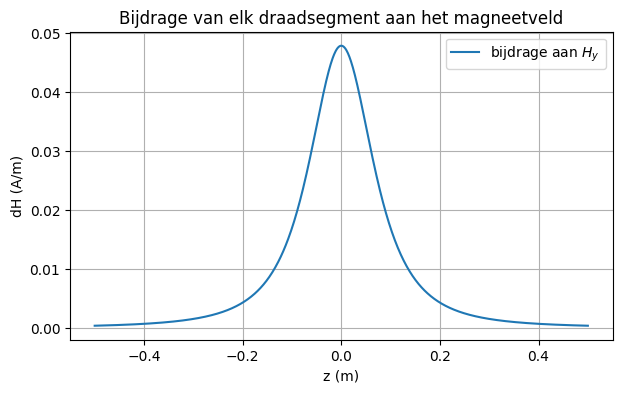

Numeriek H_totaal = [0.         9.36421586 0.        ] A/m
Analytisch H_y = 9.363856 A/m


In [7]:
I = 6.0
L = 1.0
N_seg = 1000

z_waarde = np.linspace(-L / 2, L / 2, N_seg)
dz = z_waarde[1] - z_waarde[0]
r_veld = np.array([0.1, 0.0, 0.0])

dH_list = []
for z in z_waarde:
    r_bron = np.array([0.0, 0.0, z])
    dl = np.array([0.0, 0.0, dz])
    dH = field_current_element(r_veld, r_bron, dl, I)
    dH_list.append(dH)

dH_array = np.array(dH_list)
H_totaal = np.sum(dH_array, axis=0)

plt.figure(figsize=(7, 4))
plt.plot(z_waarde, dH_array[:, 1], label=r"bijdrage aan $H_y$")
plt.title("Bijdrage van elk draadsegment aan het magneetveld")
plt.xlabel("z (m)")
plt.ylabel("dH (A/m)")
plt.grid()
plt.legend()
plt.show()

# analytische uitkomst voor een eindige rechte draad, op afstand s van het midden
s = r_veld[0]
H_analytisch = (I / (4 * np.pi * s)) * (L / np.sqrt(s**2 + (L / 2) ** 2))

print("Numeriek H_totaal =", H_totaal, "A/m")
print(f"Analytisch H_y = {H_analytisch:.6f} A/m")

## Deel 5: Numeriek berekenen van het magneetveld van een solenoïde

Nu stappen we over van één rechte draad naar een gewikkelde draad: de solenoïde.

We beschrijven het draadtraject eerst als een helix en gebruiken daarna opnieuw de wet van Biot–Savart om het veld te berekenen.

In [8]:
def parametrisatie(aantal_punten, r_sol, aantal_omwentelingen, L_sol):
    """
    Geeft de x-, y- en z-coördinaten van een solenoïde als helix terug.
    """
    t = np.linspace(0, 1, aantal_punten)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen * t)
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen * t)
    z = L_sol * t - L_sol / 2
    return x, y, z

**Opdracht 13**

a. Bepaal uit de beschikbare draadlengte hoeveel omwentelingen ongeveer mogelijk zijn.  
b. Gebruik de functie `parametrisatie(...)` om het traject van de draad van de solenoïde te tekenen.  
c. Bepaal ook de spoed in windingen per meter.

Benaderd aantal omwentelingen = 267.86
Spoed = 13392.86 windingen per meter


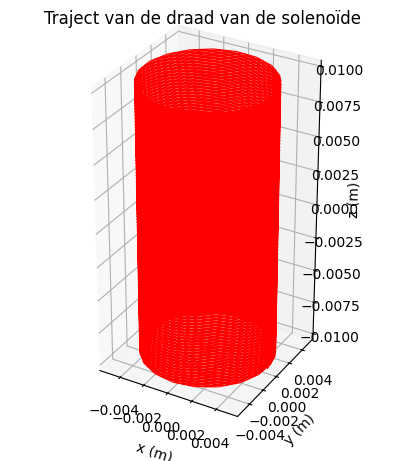

In [9]:
l_draad = l_draad_max
r_sol = 0.005
L_sol = 0.02

# benadering: draadlengte ≈ aantal windingen × omtrek
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)
print(f"Benaderd aantal omwentelingen = {aantal_omwentelingen:.2f}")

spoed = aantal_omwentelingen / L_sol
print(f"Spoed = {spoed:.2f} windingen per meter")

x, y, z = parametrisatie(
    aantal_punten=5000,
    r_sol=r_sol,
    aantal_omwentelingen=aantal_omwentelingen,
    L_sol=L_sol,
)

ax = plt.figure(figsize=(7, 5)).add_subplot(projection="3d")
ax.plot(x, y, z, "-r", linewidth=0.8)
ax.set_title("Traject van de draad van de solenoïde")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_box_aspect((1, 1, 2))
plt.show()

Het veld in een oneindig lange solenoïde is:

$
\mathbf{H} = n I \,\hat{\mathbf{z}}
$

met $n = N/L_s$ de spoed in windingen per meter.

**Opdracht 14**

Bereken het magneetveld in het midden van een eindige solenoïde numeriek en vergelijk dit met het analytische antwoord voor een oneindig lange solenoïde.  
Verhoog het aantal windingen en kijk hoe de uitkomst verandert.

N =   20 | H_num =    894.81 A/m | H_an =   1000.00 A/m
N =   50 | H_num =   2237.03 A/m | H_an =   2500.00 A/m


N =  100 | H_num =   4474.05 A/m | H_an =   5000.00 A/m


N =  150 | H_num =   6711.07 A/m | H_an =   7500.00 A/m


N =  175 | H_num =   7829.59 A/m | H_an =   8750.00 A/m


N =  200 | H_num =   8948.10 A/m | H_an =  10000.00 A/m


N =  300 | H_num =  13422.15 A/m | H_an =  15000.00 A/m


N =  500 | H_num =  22370.25 A/m | H_an =  25000.00 A/m


N = 1000 | H_num =  44740.49 A/m | H_an =  50000.00 A/m


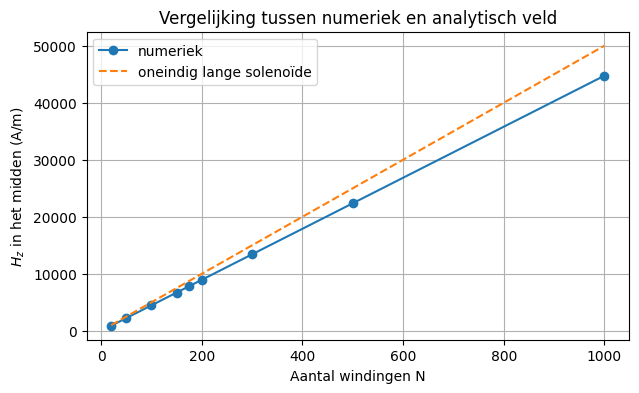

In [10]:
r_sol = 0.005
L_sol = 0.02
I = 1.0

def maak_solenoide(N_windingen, punten_per_winding=100):
    totaal_punten = int(np.ceil(N_windingen * punten_per_winding))
    return parametrisatie(totaal_punten, r_sol, N_windingen, L_sol)

def bereken_H_punt(x, y, z, r_punt, I):
    H = np.zeros(3)
    for i in range(len(x) - 1):
        r1 = np.array([x[i], y[i], z[i]])
        r2 = np.array([x[i + 1], y[i + 1], z[i + 1]])
        dl = r2 - r1
        r_bron = 0.5 * (r1 + r2)
        H += field_current_element(r_punt, r_bron, dl, I)
    return H

N_reeks = [20, 50, 100, 150, 175, 200, 300, 500, 1000]
Hz_numeriek = []
Hz_analytisch = []

for N_w in N_reeks:
    x, y, z = maak_solenoide(N_w)
    H = bereken_H_punt(x, y, z, np.array([0.0, 0.0, 0.0]), I)
    n = N_w / L_sol
    H_an = n * I

    Hz_numeriek.append(H[2])
    Hz_analytisch.append(H_an)
    print(f"N = {N_w:4d} | H_num = {H[2]:9.2f} A/m | H_an = {H_an:9.2f} A/m")

plt.figure(figsize=(7, 4))
plt.plot(N_reeks, Hz_numeriek, "o-", label="numeriek")
plt.plot(N_reeks, Hz_analytisch, "--", label="oneindig lange solenoïde")
plt.xlabel("Aantal windingen N")
plt.ylabel(r"$H_z$ in het midden (A/m)")
plt.title("Vergelijking tussen numeriek en analytisch veld")
plt.grid()
plt.legend()
plt.show()

## Deel 6: Berekenen van de krachtrespons van de actuator

Omdat onze solenoïde eindig is, is het veld niet overal gelijk.  
Daarom bekijken we nu het veld op de as van de spoel en gebruiken we dat om de energie en de kracht te benaderen.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoïde over het interval $z \in [0, 1.5L_s]$ in 25 punten.  
Vergelijk het resultaat met het ideale geval van een oneindig lange solenoïde.

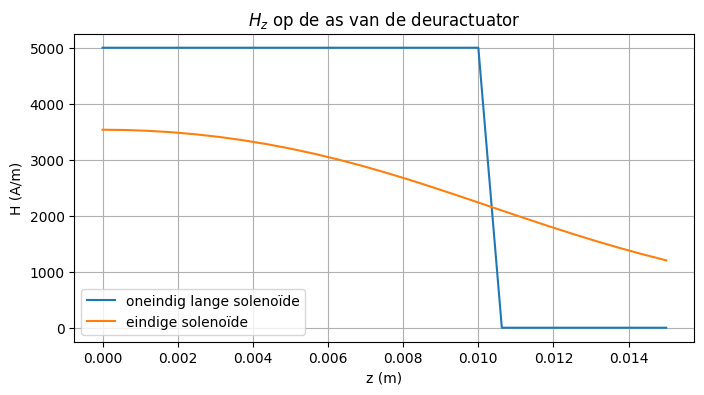

In [11]:
# Parameters van de deuractuator uit deel 3
I = I_bron
r_s = r_deur
L_s = 0.01
aantal_omwent = 100

z_ax = np.linspace(0, 1.5 * L_s, 25)

# ideaal veld voor een oneindig lange solenoïde (binnen de spoel constant, buiten nul)
H_veld_ideaal = (aantal_omwent * I / L_s) * (z_ax <= L_s).astype(float)

# analytische benadering op de as van een eindige solenoïde
H_ax = (aantal_omwent * I / (2 * L_s)) * (
    (L_s - z_ax) / np.sqrt((z_ax - L_s) ** 2 + r_s**2)
    + (L_s + z_ax) / np.sqrt((z_ax + L_s) ** 2 + r_s**2)
)

plt.figure(figsize=(8, 4))
plt.plot(z_ax, H_veld_ideaal, label="oneindig lange solenoïde")
plt.plot(z_ax, H_ax, label="eindige solenoïde")
plt.title(r"$H_z$ op de as van de deuractuator")
plt.xlabel("z (m)")
plt.ylabel("H (A/m)")
plt.grid()
plt.legend()
plt.show()

Voor de kracht gebruiken we weer de energiebenadering.  
We nemen aan dat het veld in het ijzeren deel alleen een $z$-component heeft en gebruiken de numeriek bepaalde veldsterkte op de as.

**Opdracht 16**

a. Bereken de energie van de plunjer als functie van de positie.  
b. Bepaal daaruit de kracht door numeriek te differentiëren.  
c. Vergelijk die kracht met de gevraagde kracht van de toepassing.

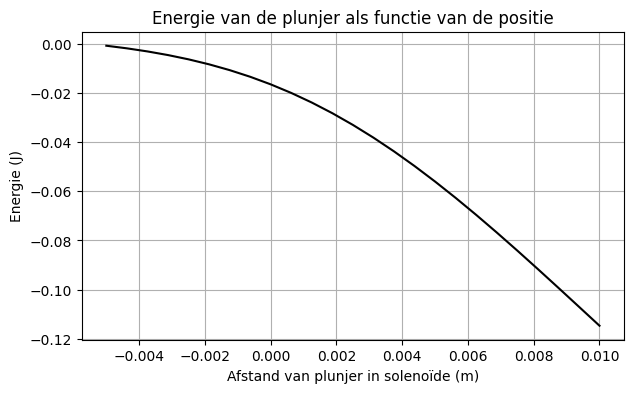

In [12]:
# energie van de plunjer als functie van de positie
dz_ax = z_ax[1] - z_ax[0]
Wz = -0.5 * np.pi * r_s**2 * np.cumsum(np.flip(mu_r * mu_0 * H_ax**2)) * dz_ax
x_pos = L_s - z_ax

plt.figure(figsize=(7, 4))
plt.plot(x_pos, np.flip(Wz), "-k")
plt.xlabel("Afstand van plunjer in solenoïde (m)")
plt.ylabel("Energie (J)")
plt.title("Energie van de plunjer als functie van de positie")
plt.grid()
plt.show()

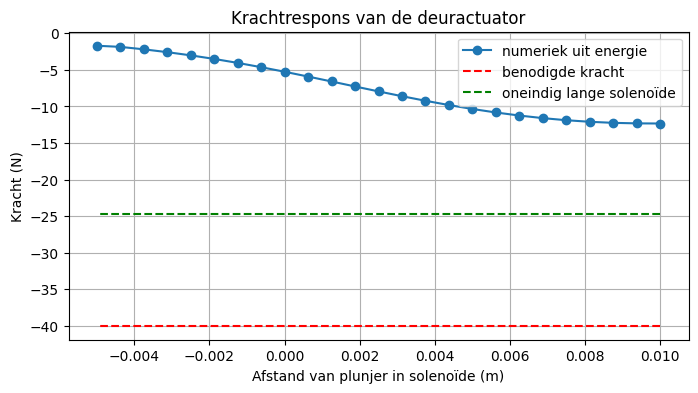

Benaderde analytische kracht = -24.67 N


In [13]:
force_analytical = -mu_0 * mu_r * np.pi * r_s**2 * aantal_omwent**2 * I**2 / (2 * L_s**2)
force_numerical = np.gradient(np.flip(Wz), x_pos)

plt.figure(figsize=(8, 4))
plt.plot(x_pos, force_numerical, "-o", label="numeriek uit energie")
plt.plot(x_pos, (-F_deur) * np.ones_like(x_pos), "--r", label="benodigde kracht")
plt.plot(x_pos, force_analytical * np.ones_like(x_pos), "--g", label="oneindig lange solenoïde")
plt.xlabel("Afstand van plunjer in solenoïde (m)")
plt.ylabel("Kracht (N)")
plt.title("Krachtrespons van de deuractuator")
plt.grid()
plt.legend()
plt.show()

print(f"Benaderde analytische kracht = {force_analytical:.2f} N")

## Deel 7: Beoordeling van de criteria

**Opdracht 17**

Kijk terug naar de criteria uit opdracht 5.  
Voldoet het gekozen ontwerp van de deuractuator aan de gestelde eisen?

Onze beoordeling van de deuractuator:

- De gevraagde kracht is **40 N**
- Uit de parameteranalyse in deel 3 bleek al dat dit ontwerp met een **9 V batterij** en **0.1 mm draad** erg moeilijk haalbaar is
- Ook uit de krachtgrafiek volgt dat de actuator met de gekozen parameters niet overtuigend aan de gevraagde kracht komt

### Conclusie
De deuractuator voldoet met deze gekozen invoer **niet goed genoeg** aan de gestelde eis.  
Voor deze toepassing is waarschijnlijk een andere combinatie nodig van:

- meer windingen
- grotere stroombron
- andere geometrie
- of een andere materiaalkeuze

**Opdracht 18**

Voer dezelfde analyse uit als in opdrachten 15 en 16 voor de twee eigen toepassingen: de klepactuator en de deurslotactuator.

Klep: gevraagde kracht = 2.0 N
Deurslot: gevraagde kracht = 5.0 N


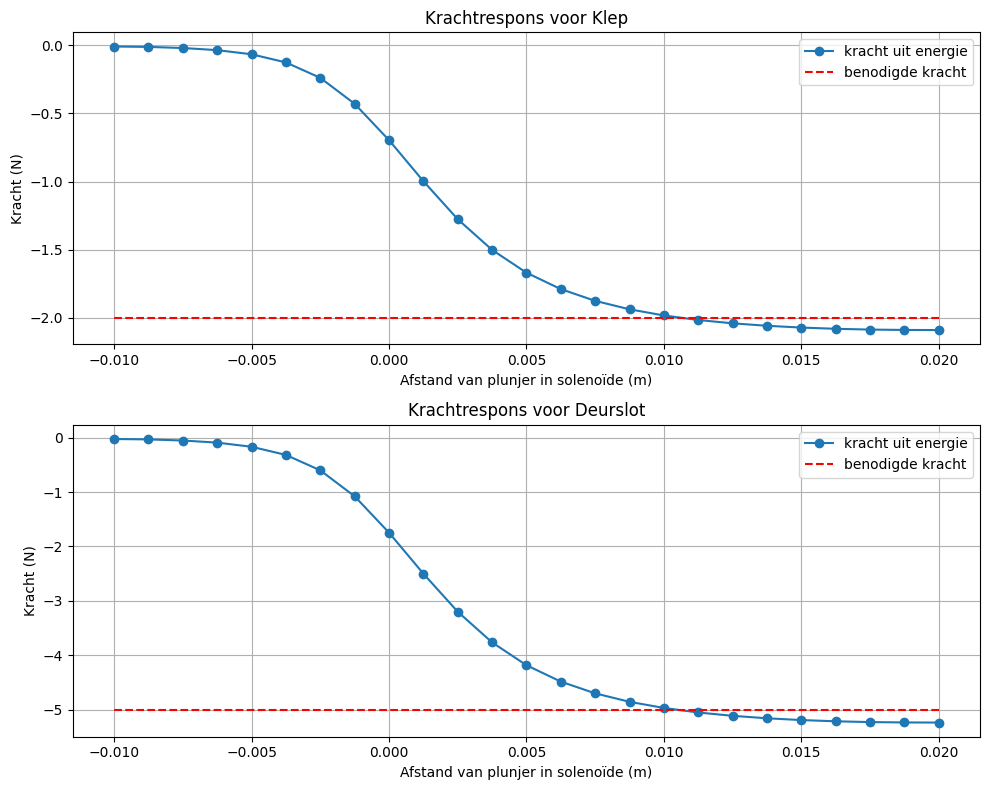

In [14]:
toepassingen = {
    "Klep": {"F_req": F_klep, "r_s": r_klep, "L_s": 0.02, "N": 120},
    "Deurslot": {"F_req": F_slot, "r_s": r_slot, "L_s": 0.02, "N": 190},
}

plt.figure(figsize=(10, 8))

for idx, (naam, pars) in enumerate(toepassingen.items(), start=1):
    z_ax = np.linspace(0, 1.5 * pars["L_s"], 25)
    H_ax = (pars["N"] * I_bron / (2 * pars["L_s"])) * (
        (pars["L_s"] - z_ax) / np.sqrt((z_ax - pars["L_s"]) ** 2 + pars["r_s"]**2)
        + (pars["L_s"] + z_ax) / np.sqrt((z_ax + pars["L_s"]) ** 2 + pars["r_s"]**2)
    )

    dz_ax = z_ax[1] - z_ax[0]
    Wz = -0.5 * np.pi * pars["r_s"]**2 * np.cumsum(np.flip(mu_r * mu_0 * H_ax**2)) * dz_ax
    x_pos = pars["L_s"] - z_ax
    F_num = np.gradient(np.flip(Wz), x_pos)

    plt.subplot(2, 1, idx)
    plt.plot(x_pos, F_num, "-o", label="kracht uit energie")
    plt.plot(x_pos, (-pars["F_req"]) * np.ones_like(x_pos), "--r", label="benodigde kracht")
    plt.title(f"Krachtrespons voor {naam}")
    plt.xlabel("Afstand van plunjer in solenoïde (m)")
    plt.ylabel("Kracht (N)")
    plt.grid()
    plt.legend()

    print(f"{naam}: gevraagde kracht = {pars['F_req']} N")

plt.tight_layout()
plt.show()

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.

b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.


**Antwoord op opdracht 19**

### a. Hebben we nu genoeg informatie?
Voor de **kracht** hebben we nu wel redelijk genoeg informatie, omdat we met de formules en grafieken een eerste inschatting kunnen maken of een ontwerp haalbaar is.

Voor de andere criteria nog niet helemaal:
- **opwarming** van de spoel hebben we nog niet echt doorgerekend
- **reactiesnelheid** hebben we ook nog niet direct gemeten
- ook verliezen en niet-ideale effecten zijn nog maar deels meegenomen

Een simpel experiment zou zijn:
1. een proefspoel wikkelen met het gekozen aantal windingen  
2. de actuator aansluiten op de 9 V batterij  
3. met een krachtmeter of bekende gewichten meten hoeveel kracht de plunjer levert  
4. daarnaast meten hoe snel de plunjer beweegt en hoe warm de spoel wordt na meerdere schakelingen

### b. Beoordeling van onze ontwerpen
- **Klep:** lijkt aan de krachteis te kunnen voldoen en is dus waarschijnlijk haalbaar.
- **Deurslot:** lijkt ook haalbaar, maar zit al dichter bij de grens.
- **Deuractuator van 40 N:** voldoet niet met de gekozen bron en draad.

Onze algemene conclusie is dus dat een kleine solenoïde-actuator voor lichte toepassingen goed mogelijk is, maar dat de zware deuractuator met deze randvoorwaarden niet haalbaar is.


Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.